# 3. Acquisition Channel → Retention/LTV
### Business Question
 > **How should we allocate user-acquisition investment to maximize long-term player value rather than short-term install volume?**
> 
 -> Which acquisition channels bring players who remain engaged and generate long-term value—not simply the largest number of installs?

This is particularly valuable for an AdTech/gaming role because it connects **UA quality → product behavior → monetization → LTV**.

### Hypothesis

**H1:** Acquisition channels differ in downstream player quality.

**H2:** Channels generating high install volume do not necessarily generate the highest retention or LTV.

**H3:** Channel quality varies by platform and geography.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/asamitakeuchi/Downloads/Data/mobile-game-ltv-forecasting-challenge/train.csv')

/var/folders/1v/2zr5v4ln72s0cjq21hbhbv3w0000gn/T/ipykernel_1861/4108302586.py:1: DtypeWarning: Columns (10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/asamitakeuchi/Downloads/Data/mobile-game-ltv-forecasting-challenge/train.csv')


In [5]:
df.head()

,user_id,platform,country_tier,channel_tier,install_day,install_week,day_since_install,event_hour,event_type,event_name,product_id,network,ad_placement,revenue_usd,ltv_d8_d180
0,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000331,6.644226
1,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,b98072a5,9e17b867,0.000226,6.644226
2,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000281,6.644226
3,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000356,6.644226
4,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,4710c070,018933a5,0.000322,6.644226


In [7]:
# map hypothetical names
channel_map = {
    '92247aa9': 'Google Ads / UAC',
    'bb16a88d': 'Meta Ads',
    '8ad56f16': 'TikTok Ads',
    '0487c9df': 'Unity Ads',
    '3bc36bb9': 'AppLovin',
    '1e3b259e': 'ironSource / LevelPlay',
    '0a1068d4': 'Liftoff / Vungle',
    '62eb5cc1': 'Moloco',
    '0a0ae9c4': 'Pangle',
    'other': 'Other',
    'c7b4e5c9': 'Mintegral',
    'be8c018e': 'Digital Turbine',
    '96e2a77d': 'Apple Search Ads',
    'a9603bc5': 'Snap Ads',
    '249fc9c1': 'Reddit Ads',
    'a4ec9600': 'Other DSP'
}

df['acquisition_channel_name'] = (
    df['channel_tier'].map(channel_map)
)

## 1. Channel quality table

In [80]:
group_col = 'acquisition_channel_name'

users = df.groupby(group_col)['user_id'].nunique()

d1_users = (df[df['install_day'] == 1].groupby(group_col)['user_id'].nunique())

d7_users = (df[df['install_day'] == 7].groupby(group_col)['user_id'].nunique())

d30_users = (df[df['install_day'] == 30].groupby(group_col)['user_id'].nunique())

ad_rev = (df[df['event_type'] == 'ad_impression'].groupby(group_col)['revenue_usd'].sum())

iap_rev = (df[df['event_name'] == 'af_purchase'].groupby(group_col)['revenue_usd'].sum())

ltv = (df.groupby([group_col, 'user_id'])['ltv_d8_d180'].first().groupby(level=0).mean())

channel_quality = pd.DataFrame({
    'Users': users,
    'Session/User': round(len(df)/users, 2),
    'D1 %': round((d1_users/users)*100.0, 2),
    'D7 %': round((d7_users/users)*100.0, 2),
    'D30 %': round((d30_users/users)*100.0, 2),
    'Ad Rev/User': ad_rev / users,
    'IAP Rev/User': iap_rev / users,
    'Ttl Rev': ad_rev + iap_rev,
    'LTV': ltv}).reset_index().sort_values('LTV', ascending=False)

channel_quality

,acquisition_channel_name,Users,Session/User,D1 %,D7 %,D30 %,Ad Rev/User,IAP Rev/User,Ttl Rev,LTV
10,Pangle,957,21950.09,3.97,3.66,0.73,0.414998,73.502182,70738.741607,109.172503
1,Apple Search Ads,98,214349.37,8.16,2.04,NaN,0.861051,6.510548,722.416744,102.116369
4,Liftoff / Vungle,1728,12156.39,5.44,3.53,0.81,0.697599,5.633537,10940.203095,67.697987
9,Other DSP,102,205943.51,2.94,7.84,NaN,NaN,1.859902,NaN,36.083862
5,Meta Ads,29459,713.07,4.70,3.75,1.97,0.771605,8.666410,278034.488662,22.535077
3,Google Ads / UAC,53214,394.75,4.19,4.66,2.50,0.739600,6.139824,366081.665062,14.697729
8,Other,500,42012.48,2.80,3.20,3.60,0.618362,3.857295,2237.828580,12.919690
0,AppLovin,2594,8098.01,2.66,3.12,0.77,0.727646,2.289568,7826.652595,7.882499
14,Unity Ads,5336,3936.70,3.28,3.13,1.50,0.449998,1.441508,10093.073595,3.588590
15,ironSource / LevelPlay,1421,14782.71,4.79,3.66,1.34,0.570429,5.226221,8237.039611,3.574625


In [ ]:
# How efficiently channels driving revenue

In [ ]:
# revenue by ad impression vs iap

## 2. Acquisition funnel
Channel → Engagement → D7 → Monetization → LTV

## 3. Channel × LTV visualization

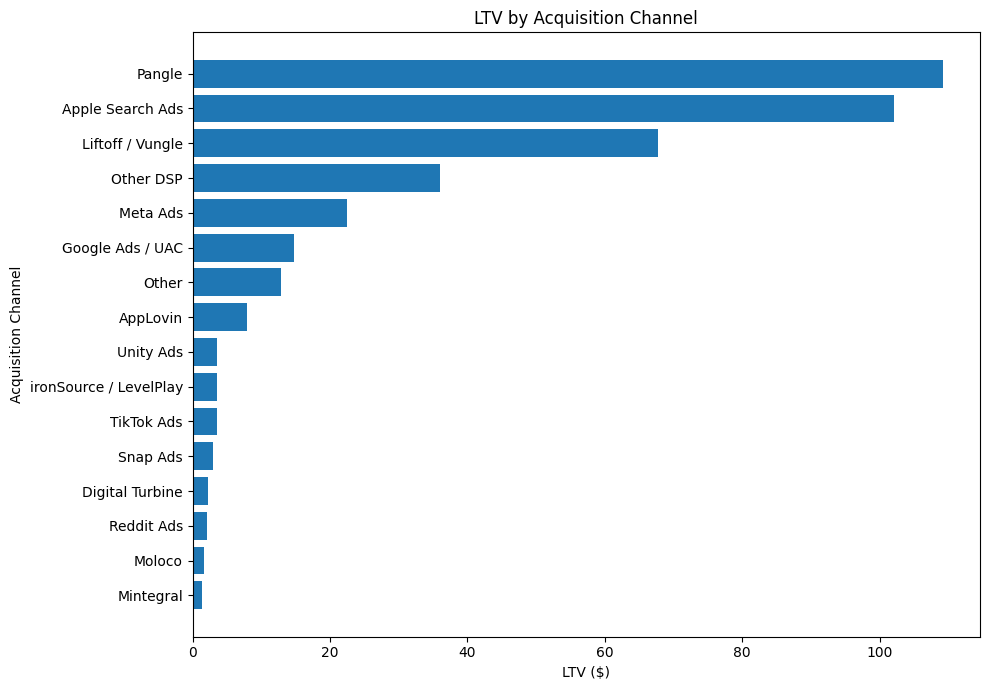

In [42]:
# Sort channels by LTV
plot_data = channel_quality.sort_values('LTV', ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data['acquisition_channel_name'],
    plot_data['LTV']
)

plt.xlabel('LTV ($)')
plt.ylabel('Acquisition Channel')
plt.title('LTV by Acquisition Channel')

plt.tight_layout()
plt.show()

## 4. Volume vs. quality scatterplot

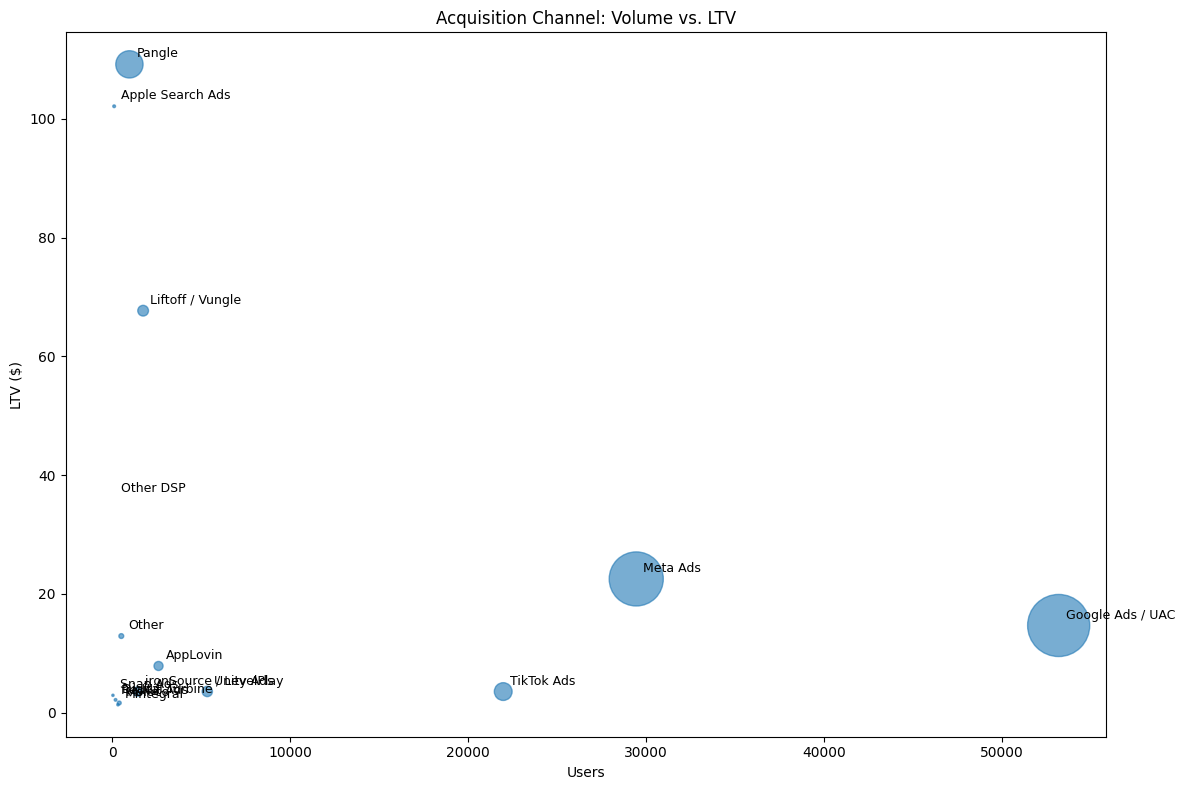

In [70]:
plt.figure(figsize=(12, 8))

# Scale total revenue into reasonable bubble sizes
bubble_size = (
    channel_quality['Ttl Rev']
    / channel_quality['Ttl Rev'].max()
    * 2000
)

plt.scatter(
    channel_quality['Users'],
    channel_quality['LTV'],
    s=bubble_size,
    alpha=0.6
)

# Label each acquisition channel
for _, row in channel_quality.iterrows():
    plt.annotate(
        row['acquisition_channel_name'],
        (row['Users'], row['LTV']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('Users')
plt.ylabel('LTV ($)')
plt.title('Acquisition Channel: Volume vs. LTV')

plt.tight_layout()
plt.show()

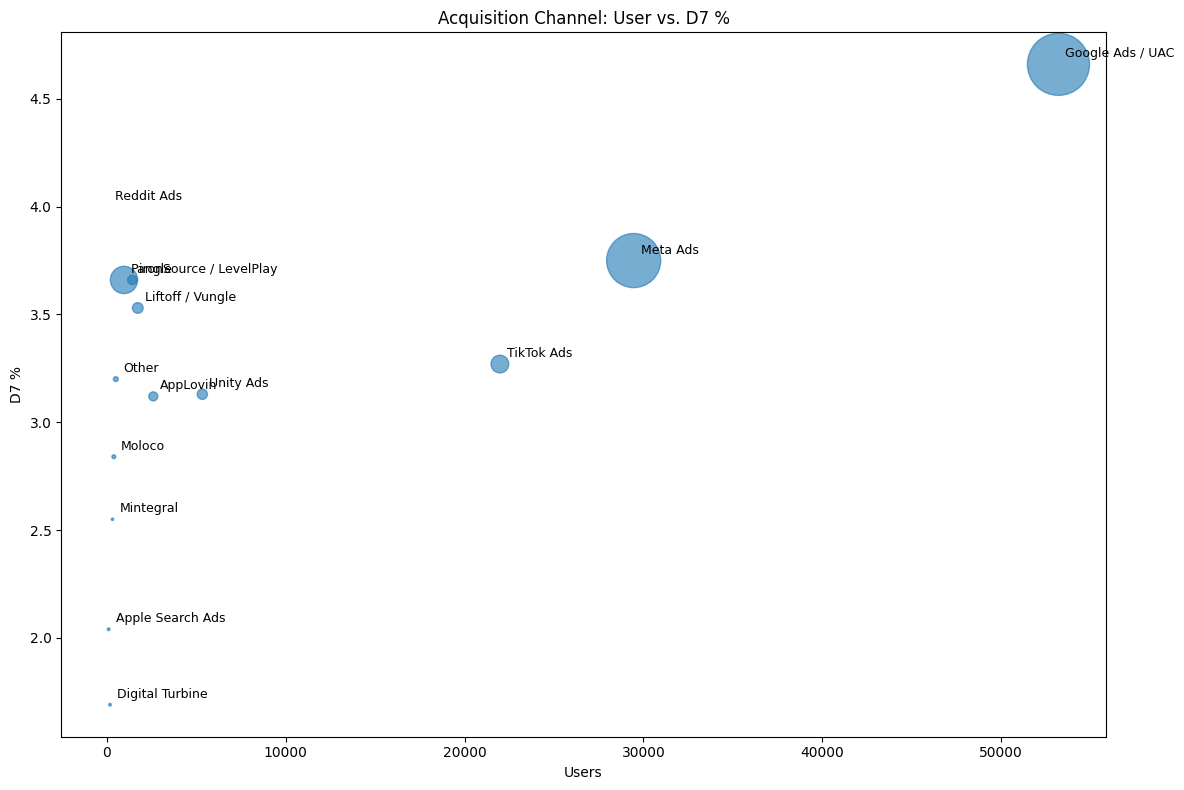

In [112]:
# Users x R7
plt.figure(figsize=(12, 8))

# Scale total revenue into reasonable bubble sizes
bubble_size = (
    channel_quality['Ttl Rev']
    / channel_quality['Ttl Rev'].max()
    * 2000
)

plt.scatter(
    channel_quality['Users'],
    channel_quality['D7 %'],
    s=bubble_size,
    alpha=0.6
)

# Label each acquisition channel
for _, row in channel_quality.iterrows():
    plt.annotate(
        row['acquisition_channel_name'],
        (row['Users'], row['D7 %']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('Users')
plt.ylabel('D7 %')
plt.title('Acquisition Channel: User vs. D7 %')

plt.tight_layout()
plt.show()

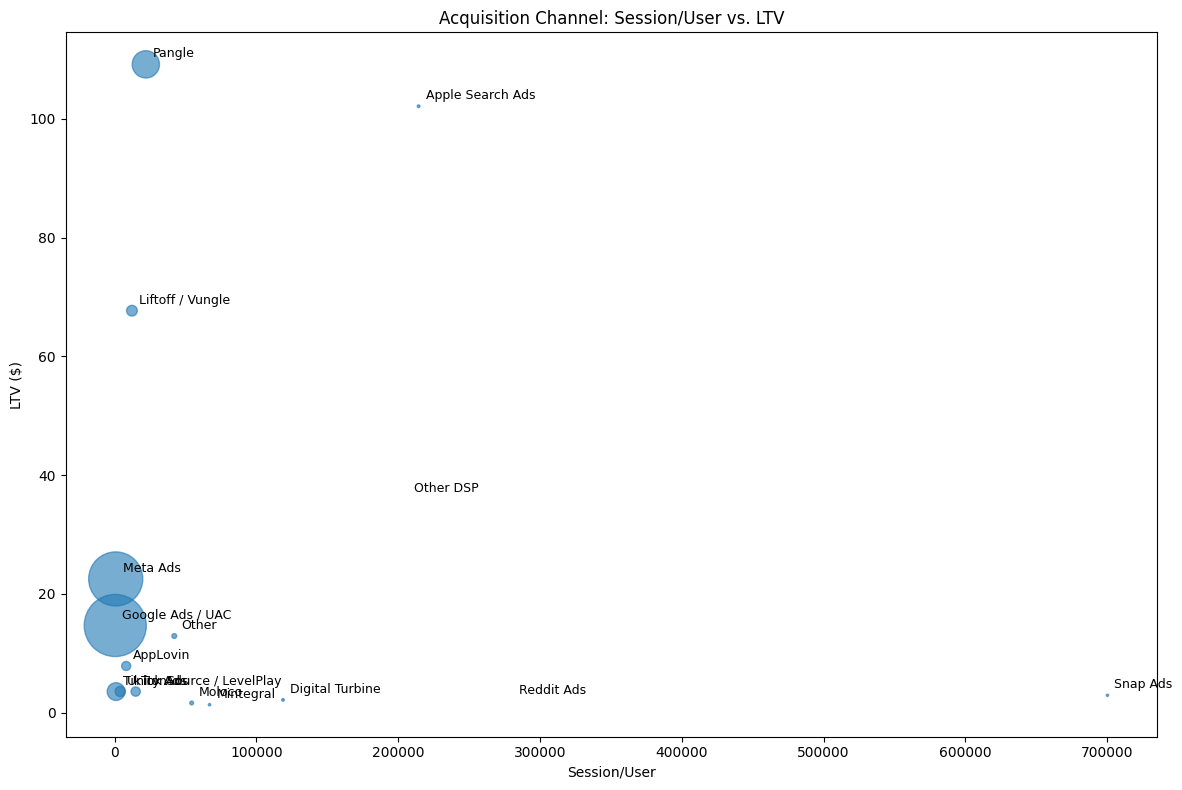

In [93]:
# Session/User x LTV
plt.figure(figsize=(12, 8))

# Scale total revenue into reasonable bubble sizes
bubble_size = (
    channel_quality['Ttl Rev']
    / channel_quality['Ttl Rev'].max()
    * 2000
)

plt.scatter(
    channel_quality['Session/User'],
    channel_quality['LTV'],
    s=bubble_size,
    alpha=0.6
)

# Label each acquisition channel
for _, row in channel_quality.iterrows():
    plt.annotate(
        row['acquisition_channel_name'],
        (row['Session/User'], row['LTV']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('Session/User')
plt.ylabel('LTV ($)')
plt.title('Acquisition Channel: Session/User vs. LTV')

plt.tight_layout()
plt.show()

In [102]:
# Ad revenue vs IAP
df.groupby(['event_type','event_name']).agg([['revenue_usd','ltv_d8_d180']].sum().round(2)

,,revenue_usd,ltv_d8_d180
event_type,event_name,,
ad_impression,ad_reward,75272.29,6.744329e+08
iap,af_purchase,713261.25,1.020903e+08
session,session_start,0.00,4.600636e+07


In [ ]:
group_col = 'acquisition_channel_name'

iap_user = df[df['event_type' == 'iap']]

# ad_user

# ttl_rev_user

In [108]:
# Ad revenue vs IAP by channel
df.groupby(['acquisition_channel_name', 'event_name'])[['revenue_usd','ltv_d8_d180']].sum().round(2).sort_values('ltv_d8_d180', ascending=False)

,,revenue_usd,ltv_d8_d180
acquisition_channel_name,event_name,,
Google Ads / UAC,ad_reward,39357.05,4.856850e+08
Meta Ads,ad_reward,22730.72,1.468563e+08
Pangle,af_purchase,70341.59,3.885489e+07
Google Ads / UAC,af_purchase,326724.62,3.172141e+07
Meta Ads,af_purchase,255303.77,2.476663e+07
Google Ads / UAC,session_start,0.00,1.614238e+07
Meta Ads,session_start,0.00,1.495002e+07
TikTok Ads,ad_reward,5025.10,1.447367e+07
Liftoff / Vungle,ad_reward,1205.45,8.021587e+06


## 5. Channel × platform matrix

In [54]:
df.head()

,user_id,platform,country_tier,channel_tier,install_day,install_week,day_since_install,event_hour,event_type,event_name,product_id,network,ad_placement,revenue_usd,ltv_d8_d180,acquisition_channel_name
0,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000331,6.644226,Google Ads / UAC
1,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,b98072a5,9e17b867,0.000226,6.644226,Google Ads / UAC
2,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000281,6.644226,Google Ads / UAC
3,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,54b36581,e7146d79,0.000356,6.644226,Google Ads / UAC
4,1,android,UZ,92247aa9,6,0,0,0,ad_impression,ad_reward,NaN,4710c070,018933a5,0.000322,6.644226,Google Ads / UAC


In [58]:
df['platform'].unique()

array(['android', 'ios'], dtype=object)

In [78]:
group_col = 'acquisition_channel_name'

android_users = df[df['platform'] == 'android'].groupby(group_col)['user_id'].nunique()

ios_users = df[df['platform'] == 'ios'].groupby(group_col)['user_id'].nunique()

android_d7 = (df[(df['platform'] == 'android') & (df['install_day'] == 1)].groupby(group_col)['user_id'].nunique())

ios_d7 = (df[(df['platform'] == 'ios') & (df['install_day'] == 1)].groupby(group_col)['user_id'].nunique())

# android_d30 = (df[(df['platform'] == 'android') & (df['install_day'] == 30)].groupby(group_col)['user_id'].nunique())

android_ltv = (df[df['platform'] == 'android'].groupby(group_col)['ltv_d8_d180'].mean())

ios_ltv = (df[df['platform'] == 'ios'].groupby(group_col)['ltv_d8_d180'].mean())

android_ttl_rev = (df[df['platform'] == 'android'].groupby(group_col)['revenue_usd'].sum())

ios_ttl_rev = (df[df['platform'] == 'ios'].groupby(group_col)['revenue_usd'].sum())

channel_platform_quality = pd.DataFrame({
    'Android Users': android_users,
    'iOS Users': ios_users,
    'Android D7': android_d7/users*100.0,
    'iOS D7': ios_d7/users*100.0,
    'Android LTV': android_ltv,
    'iOS LTV': ios_ltv,
    'Android Ttl Rev':android_ttl_rev,
    'iOS Ttl Rev': ios_ttl_rev}).reset_index().sort_values('Android LTV', ascending=False)
channel_platform_quality    

,acquisition_channel_name,Android Users,iOS Users,Android D7,iOS D7,Android LTV,iOS LTV,Android Ttl Rev,iOS Ttl Rev
1,Apple Search Ads,33.0,65.0,5.102041,3.061224,1052.954401,9.603840,616.123406,106.293338
4,Liftoff / Vungle,1162.0,573.0,4.224537,1.215278,138.117282,348.907457,4759.815945,6180.387150
5,Meta Ads,22380.0,8884.0,3.492990,1.245799,35.388068,120.424702,67009.043633,211025.445029
3,Google Ads / UAC,47541.0,10969.0,3.303642,0.911414,31.567951,57.538206,191364.188292,174717.476770
9,Other DSP,14.0,88.0,0.980392,1.960784,29.328253,34.773973,174.740000,14.970000
14,Unity Ads,3658.0,1743.0,2.117691,1.161919,28.189402,28.618335,3941.048065,6152.025530
13,TikTok Ads,21978.0,NaN,3.353353,NaN,25.216875,NaN,30046.542288,NaN
0,AppLovin,2437.0,160.0,2.313030,0.346955,23.545881,60.633945,7345.232651,481.419944
8,Other,288.0,212.0,1.600000,1.200000,13.487433,8.402124,1725.975508,511.853072
15,ironSource / LevelPlay,1416.0,5.0,4.785362,NaN,12.954610,166.819765,8205.577096,31.462515


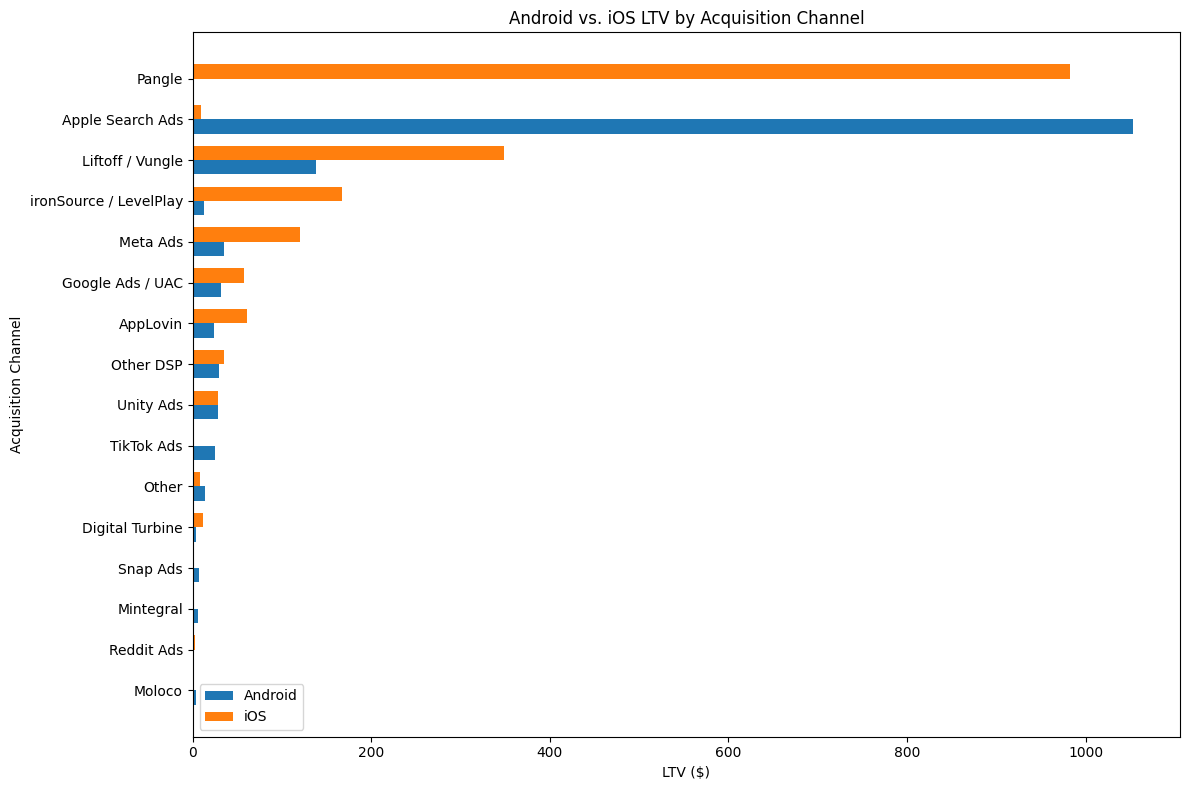

In [89]:
# Sort channels by the average of Android and iOS LTV
plot_data = channel_platform_quality.copy()

plot_data['Avg LTV'] = plot_data[['Android LTV', 'iOS LTV']].mean(axis=1)

plot_data = plot_data.sort_values('Avg LTV', ascending=True)

# Remove helper column
plot_data = plot_data.drop(columns='Avg LTV')

# Positions
y = np.arange(len(plot_data))
bar_height = 0.35

plt.figure(figsize=(12, 8))

# Android bars
plt.barh(
    y - bar_height/2,
    plot_data['Android LTV'],
    height=bar_height,
    label='Android'
)

# iOS bars
plt.barh(
    y + bar_height/2,
    plot_data['iOS LTV'],
    height=bar_height,
    label='iOS'
)

# Labels
plt.yticks(
    y,
    plot_data['acquisition_channel_name']
)

plt.xlabel('LTV ($)')
plt.ylabel('Acquisition Channel')
plt.title('Android vs. iOS LTV by Acquisition Channel')

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# scatterplot by android
plt.figure(figsize=(12, 8))

# Scale total revenue into reasonable bubble sizes
bubble_size = (
    channel_quality['Ttl Rev']
    / channel_quality['Ttl Rev'].max()
    * 2000
)

plt.scatter(
    channel_quality['Users'],
    channel_quality['LTV'],
    s=bubble_size,
    alpha=0.6
)

# Label each acquisition channel
for _, row in channel_quality.iterrows():
    plt.annotate(
        row['acquisition_channel_name'],
        (row['Users'], row['LTV']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.xlabel('Users')
plt.ylabel('LTV ($)')
plt.title('Acquisition Channel: Volume vs. LTV')

plt.tight_layout()
plt.show()